Adding new rules


Update, true Code

In [61]:
import numpy as np
import random

class EcoDrivingEnv:
    def __init__(self):
      # The Track Topography: 0 = Downhill, 1 = Flat, 2 = Uphill, 3 = Bend
        self.track = [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 3, 3, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 3, 3]
        #[1, 1, 1, 0, 0, 1, 1, 3, 3, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 3, 3, 1, 1, 1] Old array
        self.track_length = len(self.track)

        self.num_speed_states = 4
        self.num_track_states = 4
        self.num_actions = 4

        self.reset()

    def reset(self):
        self.position = 0
        self.speed = 1
        return self.get_state()

    def get_state(self):
        # The AI looks at Current, Next, and Next-Next squares
        t_current = self.track[self.position] if self.position < self.track_length else 1
        t_next = self.track[self.position + 1] if self.position + 1 < self.track_length else 1
        t_next_next = self.track[self.position + 2] if self.position + 2 < self.track_length else 1

        return (self.speed, t_current, t_next, t_next_next)

    def step(self, action):
        reward = -3  # Ticking Clock (Time Penalty)
        done = False
        current_terrain = self.track[self.position]

        if self.position + 1 < self.track_length:
            next_terrain = self.track[self.position + 1]
        else:
            next_terrain = 1

        # Apply Action Physics
        if action == 3: # BRAKE
            self.speed -= 2
            reward -= 200
        elif action == 2: # PULSE
            self.speed += 1
            reward += 10
            # RULE: Never accelerate in a curve!
            if current_terrain == 3:
                reward -= 80
            if current_terrain == 2:
                reward -= 80
        elif action == 1: # MAINTAIN
            reward -= 10
            if current_terrain == 3:
                reward -= 50
        else: # GLIDE
            # Speed drops, but doesn't go below 0 (allows gravity to save it)
            self.speed = max(0, self.speed - 1)
            reward += 20
            # RULE: Massive reward for coasting on hills
            if current_terrain in [0, 2]:
                reward += 100

        # Apply Gravity
        if current_terrain == 0:   # DOWNHILL (+1 speed)
            self.speed += 1
        elif current_terrain == 2: # UPHILL (-1 speed)
            self.speed -= 1


        # Enforce final physical limits
        self.speed = max(0, min(3, self.speed))

        # Speed Rewards
        if self.speed == 3:
            reward += 10
            # The Kinetic Energy Bonus
            if next_terrain == 2:
                reward += 80  # Massive bonus for attacking a hill with maximum momentum

            if current_terrain == 2:
                reward -= 200  # Massive punishment for turn on the motor inside the hill
        elif self.speed == 2:
            reward += 4
        elif self.speed == 1:
            reward += 2
        elif self.speed == 0:
            reward += 4
            # Evaluate the type of stall
            if next_terrain == 0:
                reward += 80  # Smart Stall. Gravity will save us on the next step
            elif current_terrain == 2 or next_terrain == 2:
                reward -= 100  # FATAL STALL. Lost all momentum on or right before a hill
                #done = True # The race to instantly end
            else:
                reward -= 40  # Regular Bad Stall: Stopped on a flat surface

        # Move forward
        self.position += 1

        # Evaluate limits and corners
        if self.position >= self.track_length:
            done = True
            reward += 100
        else:
            if self.track[self.position] == 3:
                if self.speed == 1:
                    reward += 20
                elif self.speed == 2:
                    reward += 10
                elif self.speed == 3 or self.speed == 0:
                    reward -= 150
                    done = True

        return self.get_state(), reward, done

# Quick Test
env = EcoDrivingEnv()
print("Environment upgraded. AI Vision is now 2 steps ahead.")

Environment upgraded. AI Vision is now 2 steps ahead.


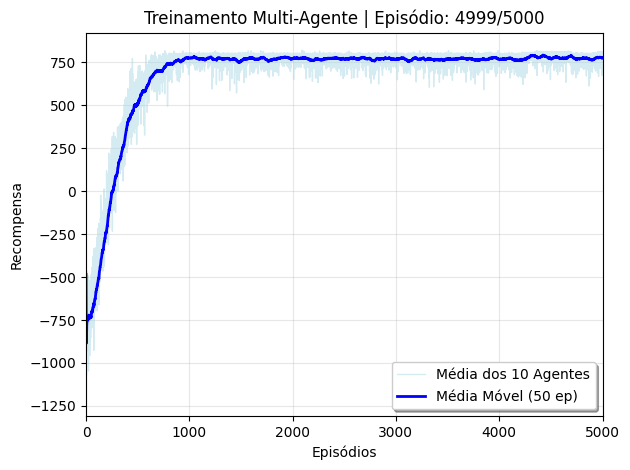


Treinamento Completo! A melhor pontuação encontrada foi: 910.0


In [62]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Q-Learning Hyperparameters
alpha = 0.1
gamma = 0.95
epsilon_start = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 5000
n_agents = 10 # Number of agents training simultaneously

# Initialize 10 distinct Q-Tables and 10 Epsilons
q_tables = [np.zeros((env.num_speed_states, env.num_track_states, env.num_track_states, env.num_track_states, env.num_actions)) for _ in range(n_agents)]
epsilons = [epsilon_start for _ in range(n_agents)]

# Tracking Metrics
avg_rewards_per_episode = []
smoothed_avg_rewards = []

# The "Snapshot" Memory for the best policy
best_reward = -float('inf')
best_q_table = None

plt.ion() # Turn on interactive plotting
plt.figure(figsize=(10, 5))

# The Training Loop
for episode in range(episodes):
    episode_rewards = [] # Stores the score of all 10 agents for this specific episode

    # Train each agent one by one for this episode
    for agent_idx in range(n_agents):
        state = env.reset()
        total_reward = 0
        done = False

        # Load this specific agent's brain and exploration rate
        agent_q_table = q_tables[agent_idx]
        epsilon = epsilons[agent_idx]

        while not done:
            speed, t_curr, t_next, t_next_next = state

            if random.uniform(0, 1) < epsilon:
                action = random.choice([0, 1, 2, 3])
            else:
                action = np.argmax(agent_q_table[speed, t_curr, t_next, t_next_next])

            next_state, reward, done = env.step(action)
            n_speed, n_curr, n_next, n_next_next = next_state

            # Bellman Update
            old_value = agent_q_table[speed, t_curr, t_next, t_next_next, action]
            next_max = np.max(agent_q_table[n_speed, n_curr, n_next, n_next_next])
            agent_q_table[speed, t_curr, t_next, t_next_next, action] = old_value + alpha * (reward + gamma * next_max - old_value)

            state = next_state
            total_reward += reward

        # Decay epsilon and record score
        epsilons[agent_idx] = max(min_epsilon, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        # CAPTURE THE BEST POLICY
        if total_reward > best_reward:
            best_reward = total_reward
            best_q_table = np.copy(agent_q_table)

    # Calculate averages for the professor's live plot
    mean_reward = np.mean(episode_rewards)
    avg_rewards_per_episode.append(mean_reward)

    window_size = 50
    smoothed_avg_rewards.append(np.mean(avg_rewards_per_episode[-window_size:]))

    # Live Plotting (Update the screen every 100 episodes to prevent freezing)
    if episode % 100 == 0 or episode == episodes - 1:
        clear_output(wait=True)
        plt.clf()

        plt.plot(avg_rewards_per_episode, color='lightblue', alpha=0.5, linewidth=1, label='Média dos 10 Agentes')
        plt.plot(smoothed_avg_rewards, color='blue', linewidth=2, label=f'Média Móvel ({window_size} ep)')

        plt.title(f"Treinamento Multi-Agente | Episódio: {episode}/{episodes}")
        plt.xlabel("Episódios")
        plt.ylabel("Recompensa")
        plt.xlim([0, episodes])
        plt.legend(loc='lower right', fancybox=True, shadow=True)
        plt.grid(alpha=0.3)
        plt.tight_layout()

        plt.show()
        plt.pause(0.001)

plt.ioff()
print(f"\nTreinamento Completo! A melhor pontuação encontrada foi: {best_reward:.1f}")

# OVERWRITE THE GLOBAL Q-TABLE
# The telemetry map cells below will automatically use the smartest brain!
q_table = best_q_table



```
# This is formatted as code
```

Path map

Capsule


Telemetria da Corrida
Passo 01 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 02 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 03 | Pista: Plano   | Vel Atual: High     -> Ação: GLIDE
Passo 04 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: GLIDE
Passo 05 | Pista: Declive | Vel Atual: Middle 1 -> Ação: GLIDE
Passo 06 | Pista: Declive | Vel Atual: Middle 1 -> Ação: GLIDE
Passo 07 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 08 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 09 | Pista: Plano   | Vel Atual: High     -> Ação: PULSE
Passo 10 | Pista: Plano   | Vel Atual: High     -> Ação: GLIDE
Passo 11 | Pista: Curva   | Vel Atual: Middle 2 -> Ação: GLIDE
Passo 12 | Pista: Curva   | Vel Atual: Middle 1 -> Ação: GLIDE
Passo 13 | Pista: Plano   | Vel Atual: Stall    -> Ação: PULSE
Passo 14 | Pista: Plano   | Vel Atual: Middle 1 -> Ação: PULSE
Passo 15 | Pista: Plano   | Vel Atual: Middle 2 -> Ação: PULSE
Passo 16 | Pista: Plano   | Vel 

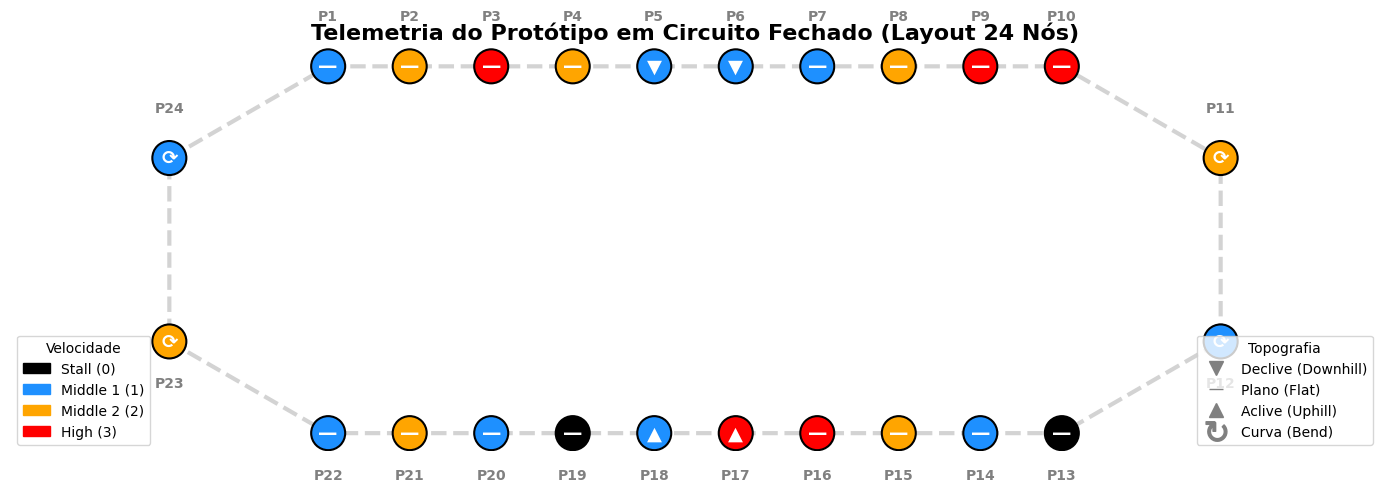

In [63]:
# Telemetria e Mapeamento do Circuito (24-Node Capsule)
import matplotlib.pyplot as plt
import numpy as np

print("\nTelemetria da Corrida")
state = env.reset()
done = False
lap_reward = 0
step_count = 0

# SYMMETRICAL CAPSULE (24 Nodes)
def generate_capsule_coords():
    comprimento = 8
    raio = 2
    x_c, y_c = [], []

    # A Reta Superior (10 nodes: P1 to P10)
    for x in np.linspace(0, comprimento, 10):
        x_c.append(x)
        y_c.append(raio)

    # B Curva Direita (2 nodes: P11 and P12)
    for theta in [np.pi/6, -np.pi/6]:
        x_c.append(comprimento + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    # C Reta Inferior (10 nodes: P13 to P22)
    for x in np.linspace(comprimento, 0, 10):
        x_c.append(x)
        y_c.append(-raio)

    # D Curva Esquerda (2 nodes: P23 and P24)
    for theta in [-5*np.pi/6, -7*np.pi/6]:
        x_c.append(0 + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    return x_c, y_c

# Load the 24 coordinates
x_coords, y_coords = generate_capsule_coords()

history_x = []
history_y = []
history_colors = []
history_topo = []

speed_colors = {0: 'black', 1: 'dodgerblue', 2: 'orange', 3: 'red'}
topo_symbols = {0: '▼', 1: '—', 2: '▲', 3: '⟳'}

slope_names = ["Declive", "Plano", "Aclive", "Curva"]
speed_names = ["Stall", "Middle 1", "Middle 2", "High"]
action_names = ["GLIDE", "MAINTAIN", "PULSE", "BRAKE"]

while not done and step_count < env.track_length:
    speed, t_curr, t_next, t_next_next = state

    action = np.argmax(q_table[speed, t_curr, t_next, t_next_next])
    next_state, reward, done = env.step(action)

    current_terrain_val = env.track[env.position-1]
    current_terrain_name = slope_names[current_terrain_val]

    print(f"Passo {step_count+1:02d} | Pista: {current_terrain_name:<7} | Vel Atual: {speed_names[speed]:<8} -> Ação: {action_names[action]}")

    history_x.append(x_coords[step_count])
    history_y.append(y_coords[step_count])
    history_colors.append(speed_colors[speed])
    history_topo.append(topo_symbols[current_terrain_val])

    state = next_state
    lap_reward += reward
    step_count += 1

print(f"\nPontuação Final da Corrida: {lap_reward} pontos")

# Desenhando o Mapa (Matplotlib)
plt.figure(figsize=(14, 5))

# Connect the nodes with a racing line
plot_x = list(history_x) + [history_x[0]]
plot_y = list(history_y) + [history_y[0]]
plt.plot(plot_x, plot_y, color='lightgray', linestyle='--', linewidth=3, zorder=1)

# Plot the telemetry dots
plt.scatter(history_x, history_y, c=history_colors, s=600, zorder=2, edgecolors='black', linewidths=1.5)

# Add Step Numbers AND Topography Symbols
for i in range(len(history_x)):
    # Offset step numbers depending on if they are on top or bottom
    y_offset = 0.5 if y_coords[i] >= 0 else -0.5
    plt.text(history_x[i], y_coords[i] + y_offset, f"P{i+1}", fontsize=10, ha='center', fontweight='bold', color='gray')

    # Topography symbols inside the dots
    plt.text(history_x[i], y_coords[i], history_topo[i], fontsize=14, ha='center', va='center', color='white', fontweight='bold')

plt.title("Telemetria do Protótipo em Circuito Fechado (Layout 24 Nós)", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.axis('off')

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Custom Legend for Speeds
speed_patches = [
    mpatches.Patch(color='black', label='Stall (0)'),
    mpatches.Patch(color='dodgerblue', label='Middle 1 (1)'),
    mpatches.Patch(color='orange', label='Middle 2 (2)'),
    mpatches.Patch(color='red', label='High (3)')
]
legend1 = plt.legend(handles=speed_patches, loc='lower left', title="Velocidade")

# Custom Legend for Topography
topo_patches = [
    mlines.Line2D([], [], color='white', marker='v', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='Declive (Downhill)'),
    mlines.Line2D([], [], color='white', marker='_', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='Plano (Flat)'),
    mlines.Line2D([], [], color='white', marker='^', markersize=10, markerfacecolor='gray', markeredgecolor='gray', label='Aclive (Uphill)'),
    mlines.Line2D([], [], color='white', marker=r'$\circlearrowright$', markersize=15, markerfacecolor='gray', markeredgecolor='gray', label='Curva (Bend)')
]
plt.legend(handles=topo_patches, loc='lower right', title="Topografia")

plt.gca().add_artist(legend1)
plt.tight_layout()
plt.show()

Brain context


Telemetria de Ações da Corrida


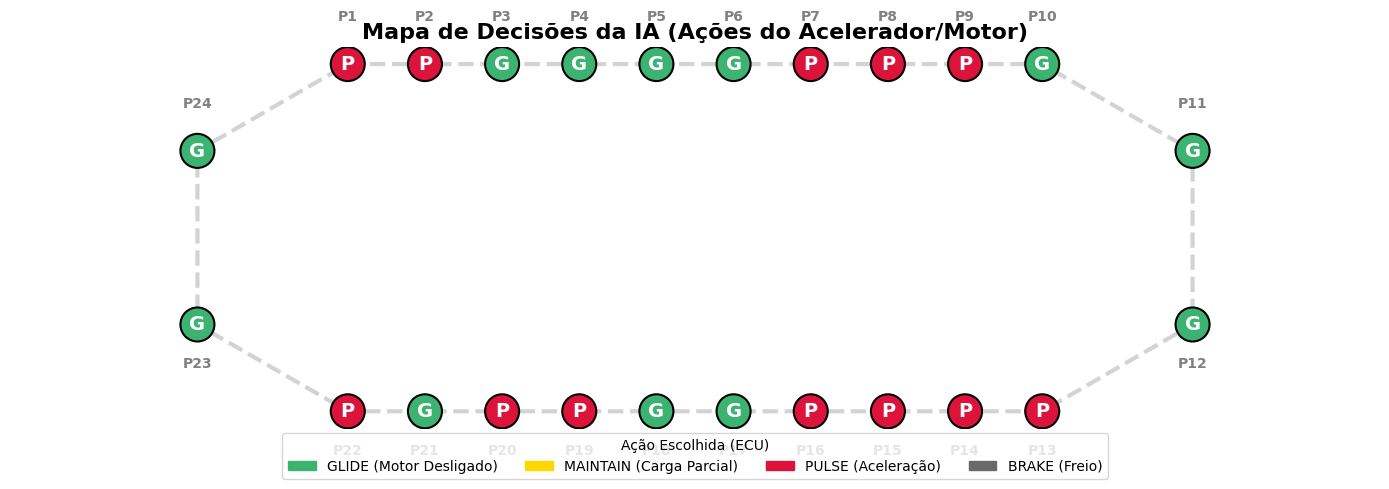

In [64]:
# Mapa de Ações do Cérebro da IA (ECU Actions)
import matplotlib.pyplot as plt
import numpy as np

print("\nTelemetria de Ações da Corrida")
state = env.reset()
done = False
lap_reward = 0
step_count = 0

# GENERATE THE PERFECT SYMMETRICAL CAPSULE (24 Nodes)
def generate_capsule_coords():
    comprimento = 8
    raio = 2
    x_c, y_c = [], []

    # A Reta Superior (10 nodes)
    for x in np.linspace(0, comprimento, 10):
        x_c.append(x)
        y_c.append(raio)

    # B Curva Direita (2 nodes)
    for theta in [np.pi/6, -np.pi/6]:
        x_c.append(comprimento + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    # C Reta Inferior (10 nodes)
    for x in np.linspace(comprimento, 0, 10):
        x_c.append(x)
        y_c.append(-raio)

    # D Curva Esquerda (2 nodes)
    for theta in [-5*np.pi/6, -7*np.pi/6]:
        x_c.append(0 + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    return x_c, y_c

x_coords, y_coords = generate_capsule_coords()

history_x = []
history_y = []
history_action_colors = []
history_action_letters = []

# New Dictionaries mapping Actions to Colors and Letters
action_colors = {0: 'mediumseagreen', 1: 'gold', 2: 'crimson', 3: 'dimgray'}
action_letters = {0: 'G', 1: 'M', 2: 'P', 3: 'B'}
action_names = ["GLIDE", "MAINTAIN", "PULSE", "BRAKE"]

while not done and step_count < env.track_length:
    speed, t_curr, t_next, t_next_next = state

    # The AI decides which pedal to press
    action = np.argmax(q_table[speed, t_curr, t_next, t_next_next])
    next_state, reward, done = env.step(action)

    # Save the spatial and action data
    history_x.append(x_coords[step_count])
    history_y.append(y_coords[step_count])
    history_action_colors.append(action_colors[action])
    history_action_letters.append(action_letters[action])

    state = next_state
    lap_reward += reward
    step_count += 1

# Desenhando o Mapa de Ações (Matplotlib)
plt.figure(figsize=(14, 5))

# Connect the nodes with a racing line
plot_x = list(history_x) + [history_x[0]]
plot_y = list(history_y) + [history_y[0]]
plt.plot(plot_x, plot_y, color='lightgray', linestyle='--', linewidth=3, zorder=1)

# Plot the telemetry dots (Colored by Action)
plt.scatter(history_x, history_y, c=history_action_colors, s=600, zorder=2, edgecolors='black', linewidths=1.5)

# Add Step Numbers AND Action Letters
for i in range(len(history_x)):
    # Offset step numbers depending on if they are on top or bottom
    y_offset = 0.5 if y_coords[i] >= 0 else -0.5
    plt.text(history_x[i], y_coords[i] + y_offset, f"P{i+1}", fontsize=10, ha='center', fontweight='bold', color='gray')

    # Action Letters inside the dots
    plt.text(history_x[i], y_coords[i], history_action_letters[i], fontsize=14, ha='center', va='center', color='white', fontweight='bold')

plt.title("Mapa de Decisões da IA (Ações do Acelerador/Motor)", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.axis('off')

import matplotlib.patches as mpatches

# Custom Legend for Actions
action_patches = [
    mpatches.Patch(color='mediumseagreen', label='GLIDE (Motor Desligado)'),
    mpatches.Patch(color='gold', label='MAINTAIN (Carga Parcial)'),
    mpatches.Patch(color='crimson', label='PULSE (Aceleração)'),
    mpatches.Patch(color='dimgray', label='BRAKE (Freio)')
]
plt.legend(handles=action_patches, loc='lower center', title="Ação Escolhida (ECU)", bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.tight_layout()
plt.show()